# K-Means Clustering

__Business Case:-__ _We have to create a model which can identify the no of cluster in given dataset._

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('Iris1.csv')

In [3]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


#### __Feature Engineering__

In [5]:
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

<Axes: xlabel='SepalLengthCm'>

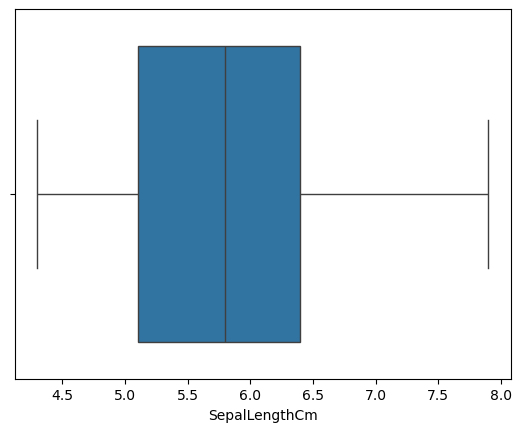

In [6]:
sns.boxplot(x=df.SepalLengthCm)

<Axes: xlabel='SepalWidthCm'>

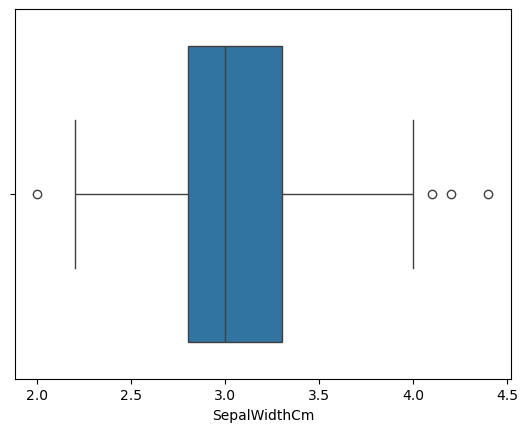

In [7]:
sns.boxplot(x=df.SepalWidthCm)

In [8]:
df.loc[(df["SepalWidthCm"] > 4.0) | (df["SepalWidthCm"] == 2.0), "SepalWidthCm"] = df.SepalWidthCm.median()

<Axes: xlabel='SepalWidthCm'>

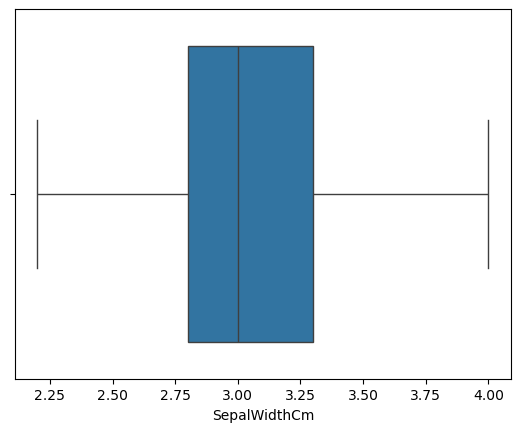

In [9]:
sns.boxplot(x=df.SepalWidthCm)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [11]:
#df.drop("SepalWidthCm", axis=1,inplace=True)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


__Feature Selection__

<Axes: >

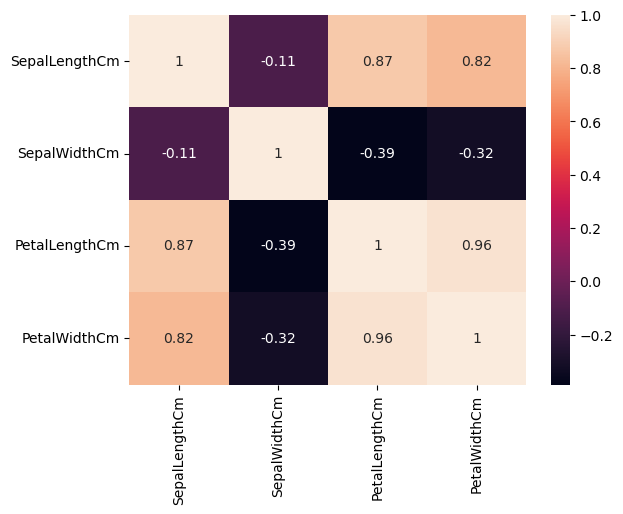

In [13]:
sns.heatmap(df.drop(["Id", "Species"],axis=1).corr(), annot=True)

In [14]:
X = df[["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]]

In [15]:
X.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


__Model Creation__

In [16]:
from sklearn.cluster import KMeans

In [17]:
km = KMeans(n_clusters=5,random_state=33)

In [18]:
km.fit(X)

C:\Users\KASHIP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,n_clusters,5
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,33
,copy_x,True
,algorithm,'lloyd'


In [19]:
km.labels_

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 4, 1, 4, 1, 4, 1, 4, 4, 4, 4, 1, 4, 1,
       4, 4, 1, 4, 1, 4, 1, 1, 1, 1, 1, 1, 1, 4, 4, 4, 4, 1, 4, 1, 1, 1,
       4, 4, 4, 1, 4, 4, 4, 4, 4, 1, 4, 4, 2, 1, 3, 2, 2, 3, 4, 3, 2, 3,
       2, 2, 2, 1, 2, 2, 2, 3, 3, 1, 2, 1, 3, 1, 2, 3, 1, 1, 2, 3, 3, 3,
       2, 1, 1, 3, 2, 2, 1, 2, 2, 2, 1, 2, 2, 2, 1, 2, 2, 1], dtype=int32)

In [20]:
color_sch = np.array(["red", "green", "blue", "purple", "orange"])

<Axes: xlabel='SepalLengthCm', ylabel='PetalLengthCm'>

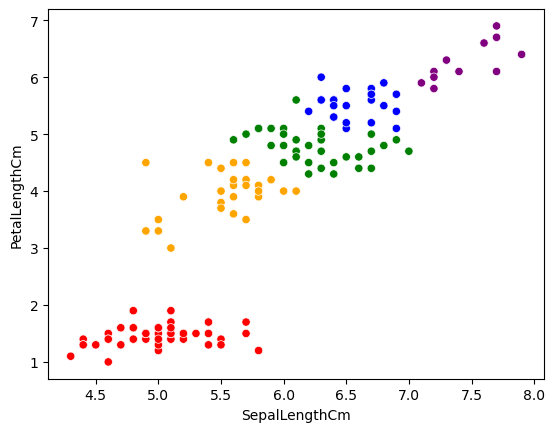

In [21]:
sns.scatterplot(x=X.SepalLengthCm, y=X.PetalLengthCm, color = color_sch[km.labels_] ) # Predicted Cluster

In [22]:
df.Species.unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [23]:
df.Species.replace({'Iris-setosa':0, 'Iris-versicolor':1, 'Iris-virginica':2}, inplace=True)

C:\Users\KASHIP\AppData\Local\Temp\ipykernel_29096\1482812932.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.Species.replace({'Iris-setosa':0, 'Iris-versicolor':1, 'Iris-virginica':2}, inplace=True)
C:\Users\KASHIP\AppData\Local\Temp\ipykernel_29096\1482812932.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_do

<Axes: xlabel='SepalLengthCm', ylabel='PetalLengthCm'>

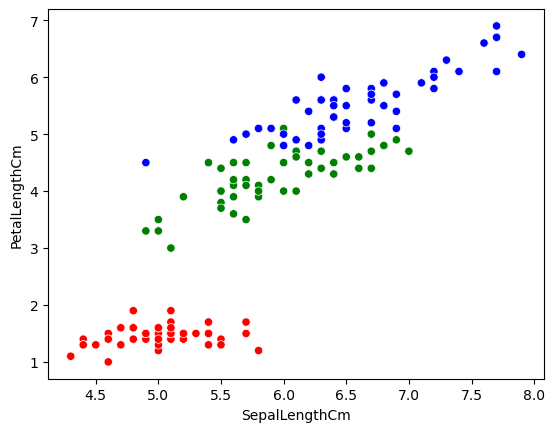

In [24]:
sns.scatterplot(x=X.SepalLengthCm, y=X.PetalLengthCm, color = color_sch[df.Species] ) # Actual Cluster

__Elbow Technique__

In [25]:
WCSS = []
for i in range(1,11):
    model = KMeans(n_clusters=i)
    model.fit(X)
    WCSS.append(model.inertia_)    # WCSS


C:\Users\KASHIP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\KASHIP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\KASHIP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\KASHIP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Wi

In [26]:
WCSS

[675.4574,
 149.3836918887376,
 76.6561051702396,
 55.25727619047618,
 44.504982051282056,
 42.48870301902399,
 36.09985555555555,
 29.990075236167346,
 30.889830006547403,
 27.589343434343437]

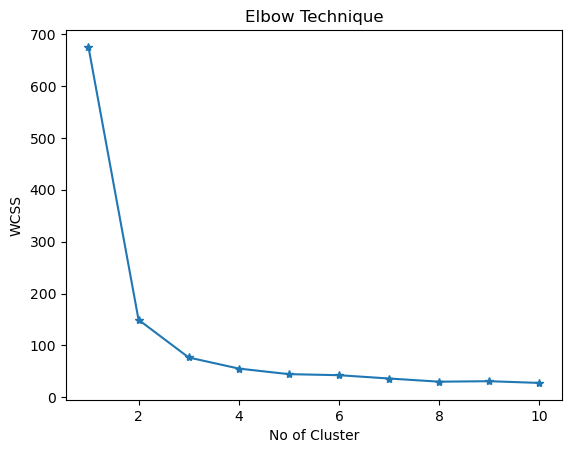

In [27]:
plt.plot(range(1,11),WCSS, marker="*")
plt.title("Elbow Technique")
plt.xlabel("No of Cluster")
plt.ylabel("WCSS")
plt.show()

In [28]:
km1=KMeans(n_clusters=3, random_state=33)
km1.fit(X)

C:\Users\KASHIP\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,33
,copy_x,True
,algorithm,'lloyd'


In [29]:
km1.labels_

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 2, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 2, 2, 2, 1, 2, 2, 2,
       2, 2, 2, 1, 1, 2, 2, 2, 2, 1, 2, 1, 2, 1, 2, 2, 1, 1, 2, 2, 2, 2,
       2, 1, 2, 2, 2, 2, 1, 2, 2, 2, 1, 2, 2, 2, 1, 2, 2, 1], dtype=int32)

<Axes: xlabel='SepalLengthCm', ylabel='PetalLengthCm'>

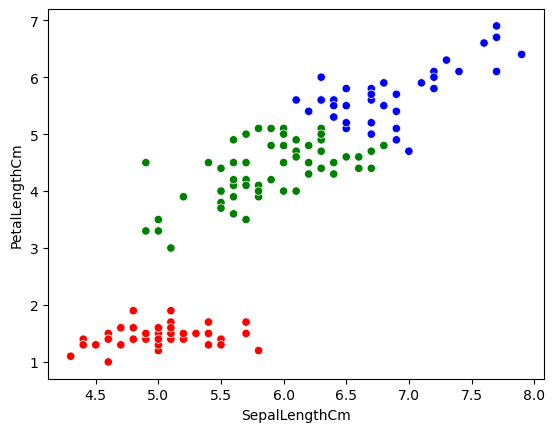

In [30]:
sns.scatterplot(x=X.SepalLengthCm, y=X.PetalLengthCm, color = color_sch[km1.labels_] ) # Actual Cluster